In [3]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 368, done.
remote: Counting objects: 100% (209/209), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 368 (delta 112), reused 102 (delta 49), pack-reused 159 (from 1)
Receiving objects: 100% (368/368), 7.60 MiB | 28.94 MiB/s, done.
Resolving deltas: 100% (174/174), done.


In [4]:
# local files
from src import utils, plotting
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet
from src.resunet import ResUNetEncoderBlock
from src.bbbc038_dataset import BBBC038Dataset
from src.center_offset_dataset import CenterOffsetDataset

import os
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar
if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train

--2026-09-13 21:49:43--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  29.4MB/s    in 2.7s    

2026-09-13 21:49:46 (29.4 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]



In [7]:
# O carregamento está implementado em src/bbbc038_dataset.py.
# Com is_training=True o retorno é:
# sample_id, image, semantic_mask, instance_map
IMG_SIZE = 128


In [8]:
class SharedMaxPoolEncoder(nn.Module):

    def __init__(self, in_channels=3):
        super().__init__()

        self.enc0 = ResUNetEncoderBlock(in_channels, 64, stride=1)

        self.enc1 = ResUNetEncoderBlock(64, 128, stride=1)

        self.enc2 = ResUNetEncoderBlock(128, 256, stride=1)

        self.bridge = ResUNetEncoderBlock(256, 512, stride=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

    def forward(self, x):

        out0 = self.enc0(x)
        size0 = out0.size()
        pooled0, indices0 = self.pool(out0)

        out1 = self.enc1(pooled0)
        size1 = out1.size()
        pooled1, indices1 = self.pool(out1)

        out2 = self.enc2(pooled1)
        size2 = out2.size()
        pooled2, indices2 = self.pool(out2)

        encoded = self.bridge(pooled2)

        return {
            "encoded": encoded,
            "skips": (out0, out1, out2),
            "indices": (indices0, indices1, indices2),
            "sizes": (size0, size1, size2),
        }

ID: 0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426
Antes del pooling: (1, 64, 128, 128)
Después del pooling: (1, 64, 64, 64)


TypeError: Axes.imshow() missing 1 required positional argument: 'X'

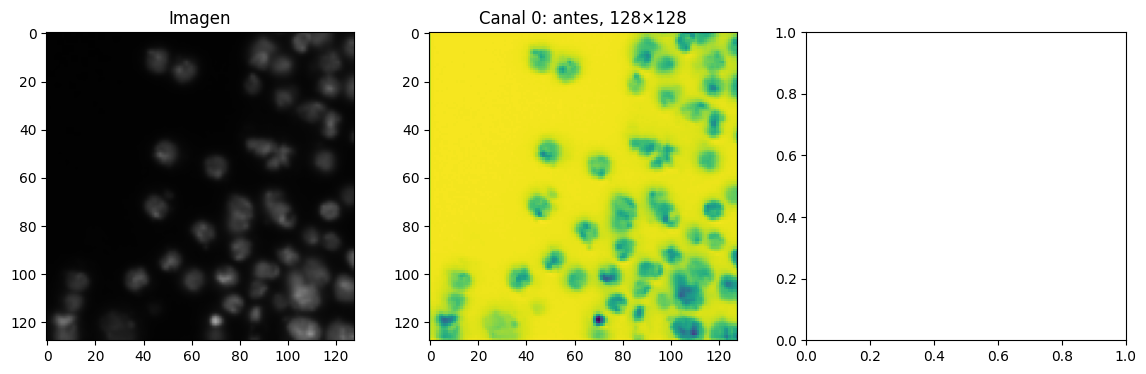

In [11]:
from pathlib import Path

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights_path = Path("/content/deep-learning-pa1/weights/weights_20260913_190326.zip")

model = ResUNet(3, 3).to(device)

model.eval()

base_dataset = BBBC038Dataset(
    is_training=True,
    path="./data/stage1_train",
    img_size=128
)

center_dataset = CenterOffsetDataset(base_dataset)

image_id, image, heatmap, offsets, offset_mask = center_dataset[6]

pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2,
    return_indices=True
)

with torch.no_grad():

    image_batch = image.unsqueeze(0).to(device)

    features = model.enc0(image_batch)

    pooled, indices = pool(features)

print("ID:", image_id)
print("Antes del pooling:", tuple(features.shape))
print("Después del pooling:", tuple(pooled.shape))

channel = 0

before = features[0, channel].cpu().numpy()
after = pooled[0, channel].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image.permute(1, 2, 0).cpu().numpy())
axes[0].set_title("Imagen")

axes[1].imshow(
    before,
    cmap="viridis",
    vmin=before.min(),
    vmax=before.max(),
    interpolation="nearest"
)
axes[1].set_title(f"Canal {channel}: antes, 128×128")

axes[2].imshow(
    cmap="viridis",
    vmin=before.min(),
    vmax=before.max(),
    interpolation="nearest"
)
axes[2].set_title(f"Canal {channel}: después, 64×64")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
image_id, image, heatmap, offsets, offset_mask = center_dataset[6]

pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2,
    return_indices=True
)

model.eval()

with torch.no_grad():

    image_batch = image.unsqueeze(0).to(device)

    features = model.enc0(image_batch)

    pooled, indices = pool(features)


In [13]:
print("Antes:", tuple(features.shape))
print("Depois:", tuple(pooled.shape))

Antes: (1, 64, 128, 128)
Depois: (1, 64, 64, 64)


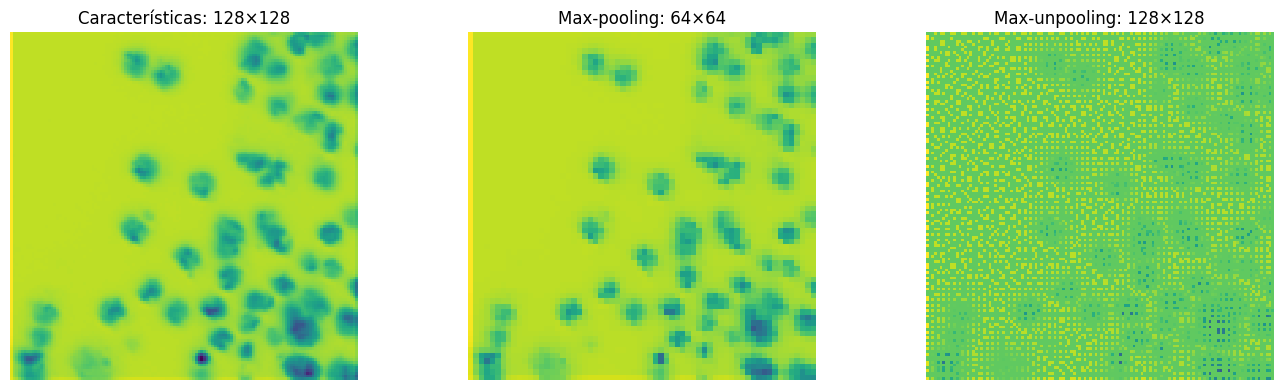

In [14]:
unpool = nn.MaxUnpool2d(
    kernel_size=2,
    stride=2
)

with torch.no_grad():
    restored = unpool(
        pooled,
        indices,
        output_size=features.size()
    )

channel = 63

before = features[0, channel].cpu().numpy()
after = pooled[0, channel].cpu().numpy()
unpooled = restored[0, channel].cpu().numpy()

vmin = min(before.min(), 0.0)
vmax = max(before.max(), 0.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, values, title in zip(
    axes,
    [before, after, unpooled],
    [
        "Características: 128×128",
        "Max-pooling: 64×64",
        "Max-unpooling: 128×128"
    ]
):
    ax.imshow(
        values,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
class MaxUnpoolDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.projection = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

        self.unpool = nn.MaxUnpool2d(
            kernel_size=2,
            stride=2
        )

        self.refine = ResUNetEncoderBlock(
            out_channels,
            out_channels,
            stride=1
        )

    def forward(self, x, indices, output_size):
        x = self.projection(x)

        x = self.unpool(
            x,
            indices,
            output_size=output_size
        )

        return self.refine(x)

In [16]:
class CenterOffsetMaxUnpool(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.encoder = SharedMaxPoolEncoder(
            in_channels=in_channels
        )

        self.dec2 = MaxUnpoolDecoderBlock(512, 256)
        self.dec1 = MaxUnpoolDecoderBlock(256, 128)
        self.dec0 = MaxUnpoolDecoderBlock(128, 64)

        # Canal 0: heatmap
        # Canal 1: dx
        # Canal 2: dy
        self.ending = nn.Conv2d(
            64,
            3,
            kernel_size=1
        )

    def forward(self, x):
        features = self.encoder(x)

        indices0, indices1, indices2 = features["indices"]
        size0, size1, size2 = features["sizes"]

        y = features["encoded"]

        # Recuperar resolucao
        y = self.dec2(y, indices2, size2)
        y = self.dec1(y, indices1, size1)
        y = self.dec0(y, indices0, size0)

        return self.ending(y)

In [17]:
unpool_model = CenterOffsetMaxUnpool().to(device)
unpool_model.eval()

sample_id, image, heatmap, offsets, offset_mask = center_dataset[6]

with torch.no_grad():
    prediction = unpool_model(
        image.unsqueeze(0).to(device)
    )

expected_shape = (1, 3, *image.shape[-2:])

assert tuple(prediction.shape) == expected_shape

print("ID:", sample_id)
print("Salida:", tuple(prediction.shape))
print("Heatmap:", tuple(prediction[:, 0:1].shape))
print("Offsets:", tuple(prediction[:, 1:3].shape))

ID: 0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426
Salida: (1, 3, 128, 128)
Heatmap: (1, 1, 128, 128)
Offsets: (1, 2, 128, 128)


In [18]:
from src.resunet import ResUNetDecoderBlock


class CenterOffsetSkip(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.encoder = SharedMaxPoolEncoder(in_channels)

        self.dec2 = ResUNetDecoderBlock(512, 256, 256)
        self.dec1 = ResUNetDecoderBlock(256, 128, 128)
        self.dec0 = ResUNetDecoderBlock(128, 64, 64)

        self.ending = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        out0, out1, out2 = features['skips']

        y = features['encoded']
        y = self.dec2(y, out2)
        y = self.dec1(y, out1)
        y = self.dec0(y, out0)

        return self.ending(y)


In [19]:
class ImagePoolingContext(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.projection = nn.Conv2d(512, 128, kernel_size=1)
        self.fuse = nn.Conv2d(512 + 128, 512, kernel_size=1)

    def forward(self, x):
        context = self.pool(x)
        context = F.relu(self.projection(context))

        context = F.interpolate(
            context,
            size=x.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        x = torch.cat([x, context], dim=1)
        return F.relu(self.fuse(x))


In [20]:
class CenterOffsetSkipContext(CenterOffsetSkip):
    def __init__(self, in_channels=3):
        super().__init__(in_channels)
        self.context = ImagePoolingContext()

    def forward(self, x):
        features = self.encoder(x)
        out0, out1, out2 = features['skips']

        y = self.context(features['encoded'])
        y = self.dec2(y, out2)
        y = self.dec1(y, out1)
        y = self.dec0(y, out0)

        return self.ending(y)


In [21]:
from torch.utils.data import Subset

train_dataset, val_dataset, test_dataset = random_split(
    center_dataset,
    [0.8, 0.1, 0.1],
    generator=torch.Generator().manual_seed(42)
)

print('Treino:', len(train_dataset))
print('Validação:', len(val_dataset))
print('Teste:', len(test_dataset))

output_dir = Path('./outputs/parte3_simples')
output_dir.mkdir(parents=True, exist_ok=True)

split_rows = []
for split_name, subset in [
    ('train', train_dataset),
    ('val', val_dataset),
    ('test', test_dataset)
]:
    for index in subset.indices:
        split_rows.append({
            'split': split_name,
            'index': index,
            'image_id': base_dataset.ids[index]
        })

split_df = pd.DataFrame(split_rows)
split_path = output_dir / 'split.csv'
if split_path.exists():
    saved_split = pd.read_csv(split_path)
    assert saved_split.equals(split_df), 'A divisão mudou. Use outra pasta de resultados.'
else:
    split_df.to_csv(split_path, index=False)


Treino: 536
Validação: 67
Teste: 67


In [22]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def build_models(seed):
    set_seed(seed)
    skip = CenterOffsetSkip()

    set_seed(seed)
    max_unpool = CenterOffsetMaxUnpool()

    set_seed(seed)
    skip_context = CenterOffsetSkipContext()

    max_unpool.encoder.load_state_dict(skip.encoder.state_dict())
    max_unpool.ending.load_state_dict(skip.ending.state_dict())

    skip_context.encoder.load_state_dict(skip.encoder.state_dict())
    skip_context.ending.load_state_dict(skip.ending.state_dict())
    skip_context.dec2.load_state_dict(skip.dec2.state_dict())
    skip_context.dec1.load_state_dict(skip.dec1.state_dict())
    skip_context.dec0.load_state_dict(skip.dec0.state_dict())

    return {
        'skip': skip,
        'max_unpool': max_unpool,
        'skip_context': skip_context
    }


In [23]:
# Testa os shapes e conta os parâmetros antes de treinar.
models = build_models(42)
parameter_rows = []

for name, current_model in models.items():
    current_model.eval()

    with torch.no_grad():
        output = current_model(image.unsqueeze(0).cpu())

    assert output.shape == (1, 3, IMG_SIZE, IMG_SIZE)
    print(name, tuple(output.shape))

    parameter_rows.append({
        'architecture': name,
        'parameters': sum(p.numel() for p in current_model.parameters())
    })

parameters_df = pd.DataFrame(parameter_rows)
parameters_df.to_csv(output_dir / 'parameters.csv', index=False)
display(parameters_df)

del models, current_model, output

model.cpu()
unpool_model.cpu()


skip (1, 3, 128, 128)
max_unpool (1, 3, 128, 128)
skip_context (1, 3, 128, 128)


,architecture,parameters
0,skip,11318601
1,max_unpool,6671497
2,skip_context,11712457


CenterOffsetMaxUnpool(
  (encoder): SharedMaxPoolEncoder(
    (enc0): ResUNetEncoderBlock(
      (seq): Sequential(
        (0): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU()
        (2): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU()
        (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (shortcut): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (enc1): ResUNetEncoderBlock(
      (seq): Sequential(
        (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU()
        (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU()
        (5): Conv2d(128, 128, kernel_size=(3, 3), stride

mesma perda

In [24]:
heatmap_loss_fn = nn.MSELoss()
offset_loss_fn = nn.L1Loss(reduction='none')
offset_loss_weight = 1.0


def compute_loss(pred, heatmap, offsets, offset_mask):
    pred_heatmap = pred[:, 0:1]
    pred_offsets = pred[:, 1:3]

    loss_heatmap = heatmap_loss_fn(pred_heatmap, heatmap)

    raw_offset_loss = offset_loss_fn(pred_offsets, offsets)
    mask_2ch = offset_mask.expand_as(raw_offset_loss)

    loss_offsets = (
        (raw_offset_loss * mask_2ch).sum()
        / mask_2ch.sum().clamp(min=1.0)
    )

    return loss_heatmap + offset_loss_weight * loss_offsets


In [25]:
@torch.no_grad()
def validation_loss(model, loader):
    model.eval()

    heatmap_error = 0.0
    offset_error = 0.0
    heatmap_pixels = 0
    offset_pixels = 0

    for _, image, heatmap, offsets, offset_mask in loader:
        image = image.to(device)
        heatmap = heatmap.to(device)
        offsets = offsets.to(device)
        offset_mask = offset_mask.to(device)

        pred = model(image)
        mask_2ch = offset_mask.expand_as(offsets)

        heatmap_error += ((pred[:, 0:1] - heatmap) ** 2).sum().item()
        heatmap_pixels += heatmap.numel()

        offset_error += (
            torch.abs(pred[:, 1:3] - offsets) * mask_2ch
        ).sum().item()
        offset_pixels += mask_2ch.sum().item()

    return (
        heatmap_error / heatmap_pixels
        + offset_loss_weight * offset_error / max(offset_pixels, 1)
    )


In [26]:
def train_model(model, name, seed, epochs=25):
    set_seed(seed)
    model = model.to(device)

    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed)
    )
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    best_val_loss = float('inf')
    history = []

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        n_images = 0

        for _, image, heatmap, offsets, offset_mask in train_loader:
            image = image.to(device)
            heatmap = heatmap.to(device)
            offsets = offsets.to(device)
            offset_mask = offset_mask.to(device)

            optimizer.zero_grad()
            pred = model(image)
            loss = compute_loss(pred, heatmap, offsets, offset_mask)

            if not torch.isfinite(loss).item():
                raise RuntimeError('Perda não finita.')

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * image.shape[0]
            n_images += image.shape[0]

        # Média dos losses dos batches, ponderada pelo tamanho do batch.
        train_loss = train_loss_sum / n_images
        val_loss = validation_loss(model, val_loader)
        if not np.isfinite(val_loss):
            raise RuntimeError('Perda de validação não finita.')

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                model.state_dict(),
                output_dir / f'{name}_seed{seed}.pt'
            )

        pd.DataFrame(history).to_csv(
            output_dir / f'{name}_seed{seed}_history.csv', index=False
        )

        print(
            f'{name} | seed={seed} | época={epoch + 1}/{epochs} | '
            f'train={train_loss:.4f} | val={val_loss:.4f}',
            flush=True
        )

    model.cpu()
    return history


In [27]:
SHOULD_TRAIN = True
SEEDS = [42, 123]
EPOCHS = 25

if SHOULD_TRAIN:
    for seed in SEEDS:
        models = build_models(seed)

        for name, current_model in models.items():
            train_model(current_model, name, seed, epochs=EPOCHS)

        del models, current_model


skip | seed=42 | época=1/25 | train=2.2856 | val=2.2120
skip | seed=42 | época=2/25 | train=1.6099 | val=1.8904
skip | seed=42 | época=3/25 | train=1.4044 | val=1.8882
skip | seed=42 | época=4/25 | train=1.3045 | val=1.6068
skip | seed=42 | época=5/25 | train=1.1919 | val=1.5215
skip | seed=42 | época=6/25 | train=1.1183 | val=1.5218
skip | seed=42 | época=7/25 | train=1.0717 | val=1.5605
skip | seed=42 | época=8/25 | train=1.1246 | val=1.4368
skip | seed=42 | época=9/25 | train=1.0292 | val=1.3770
skip | seed=42 | época=10/25 | train=1.0112 | val=1.3982
skip | seed=42 | época=11/25 | train=0.9300 | val=1.4157
skip | seed=42 | época=12/25 | train=0.9270 | val=1.4203
skip | seed=42 | época=13/25 | train=0.8858 | val=1.3325
skip | seed=42 | época=14/25 | train=0.8672 | val=1.3816
skip | seed=42 | época=15/25 | train=0.8188 | val=1.2797
skip | seed=42 | época=16/25 | train=0.7897 | val=1.2320
skip | seed=42 | época=17/25 | train=0.7291 | val=1.2573
skip | seed=42 | época=18/25 | train=0.7

In [28]:
from pathlib import Path

output_dir = Path("./outputs/parte3_simples")

for path in sorted(output_dir.glob("*")):
    print(path.name)

max_unpool_seed123.pt
max_unpool_seed123_history.csv
max_unpool_seed42.pt
max_unpool_seed42_history.csv
parameters.csv
skip_context_seed123.pt
skip_context_seed123_history.csv
skip_context_seed42.pt
skip_context_seed42_history.csv
skip_seed123.pt
skip_seed123_history.csv
skip_seed42.pt
skip_seed42_history.csv
split.csv


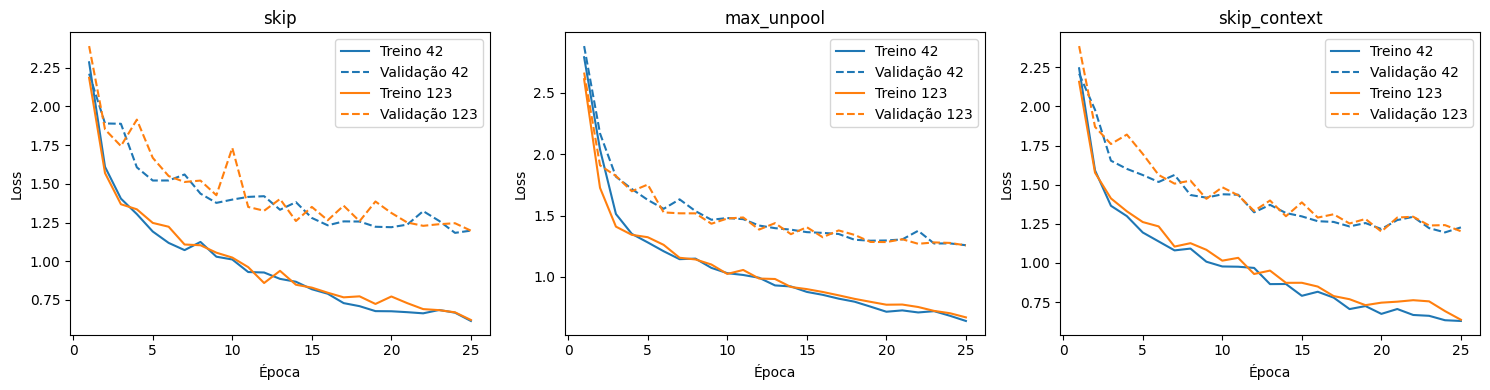

In [29]:
names = ['skip', 'max_unpool', 'skip_context']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, names):
    for seed in SEEDS:
        history = pd.read_csv(output_dir / f'{name}_seed{seed}_history.csv')

        line, = ax.plot(history['epoch'], history['train_loss'], label=f'Treino {seed}')
        ax.plot(
            history['epoch'], history['val_loss'],
            linestyle='--', color=line.get_color(), label=f'Validação {seed}'
        )

    ax.set_title(name)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / 'loss.png', dpi=150)
plt.show()


In [30]:
THRESHOLD = 0.3
NMS_KERNEL = 7
TOP_K = 50


def prediction_to_instances(pred):
    pred = pred.detach().cpu()
    h, w = pred.shape[-2:]

    if not torch.isfinite(pred).all().item():
        raise ValueError('Predição contém NaN ou Inf.')

    xs, ys = utils.find_peaks(
        pred[0].numpy(),
        threshold=THRESHOLD,
        nms_kernel=NMS_KERNEL,
        top_k=TOP_K
    )

    if len(xs) == 0:
        return np.zeros((h, w), dtype=np.int64)

    centroids = np.stack([ys, xs], axis=1)
    bg_mask = pred[0] < THRESHOLD

    positions = torch.stack(torch.meshgrid(
        torch.arange(h, dtype=torch.float32),
        torch.arange(w, dtype=torch.float32),
        indexing='ij'
    ))

    positions[0] += pred[2]  # linha + dy
    positions[1] += pred[1]  # coluna + dx

    instances = utils.assign_instances(
        positions,
        centroids,
        background_mask=bg_mask
    )

    return instances.numpy()


In [31]:
@torch.no_grad()
def evaluate_model(model, name, seed):
    model.eval()

    instance_test_dataset = Subset(base_dataset, test_dataset.indices)
    instance_test_loader = DataLoader(
        instance_test_dataset, batch_size=1, shuffle=False
    )

    per_image_rows = []
    per_threshold_rows = []

    for image_id, image, semantic_mask, gt_map in instance_test_loader:
        pred = model(image.to(device))[0]
        pred_map = prediction_to_instances(pred)
        gt_map = gt_map[0].numpy()

        threshold_results = utils.evaluate_instance_prediction(gt_map, pred_map)

        n_gt = len(utils.get_instance_ids(gt_map))
        n_pred = len(utils.get_instance_ids(pred_map))

        gt_binary = torch.from_numpy((gt_map > 0).astype(np.float32))
        pred_binary = torch.from_numpy((pred_map > 0).astype(np.float32))

        if n_gt == 0 and n_pred == 0:
            iou = dice = 1.0
        else:
            iou = float(utils.iou_score(gt_binary, pred_binary))
            dice = float(utils.dice_score(gt_binary, pred_binary))

        per_image_rows.append({
            'architecture': name,
            'seed': seed,
            'image_id': image_id[0],
            'n_gt': n_gt,
            'n_pred': n_pred,
            'count_absolute_error': abs(n_pred - n_gt),
            'mAP': np.mean([result['AP'] for result in threshold_results]),
            'IoU': iou,
            'Dice': dice
        })

        for result in threshold_results:
            per_threshold_rows.append({
                'architecture': name,
                'seed': seed,
                'image_id': image_id[0],
                **result
            })

    return pd.DataFrame(per_image_rows), pd.DataFrame(per_threshold_rows)


In [32]:
model_classes = {
    'skip': CenterOffsetSkip,
    'max_unpool': CenterOffsetMaxUnpool,
    'skip_context': CenterOffsetSkipContext
}

# Não avalia corridas que ainda não terminaram as 25 épocas.
for name in names:
    for seed in SEEDS:
        history = pd.read_csv(output_dir / f'{name}_seed{seed}_history.csv')
        assert len(history) == EPOCHS and history['epoch'].iloc[-1] == EPOCHS

all_images = []
all_thresholds = []
results = []

for name in names:
    for seed in SEEDS:
        current_model = model_classes[name]().to(device)
        current_model.load_state_dict(torch.load(
            output_dir / f'{name}_seed{seed}.pt',
            map_location=device,
            weights_only=True
        ))

        image_results, threshold_results = evaluate_model(current_model, name, seed)

        all_images.append(image_results)
        all_thresholds.append(threshold_results)

        results.append({
            'architecture': name,
            'seed': seed,
            'mAP': image_results['mAP'].mean(),
            'MAE': image_results['count_absolute_error'].mean(),
            'IoU': image_results['IoU'].mean(),
            'Dice': image_results['Dice'].mean()
        })

        print(results[-1])
        current_model.cpu()
        del current_model

results_df = pd.DataFrame(results)
per_image_df = pd.concat(all_images, ignore_index=True)
per_threshold_df = pd.concat(all_thresholds, ignore_index=True)

results_df.to_csv(output_dir / 'results_per_seed.csv', index=False)
per_image_df.to_csv(output_dir / 'results_per_image.csv', index=False)
per_threshold_df.to_csv(output_dir / 'results_per_threshold.csv', index=False)

display(results_df)


{'architecture': 'skip', 'seed': 42, 'mAP': np.float64(0.0953642238785621), 'MAE': np.float64(22.074626865671643), 'IoU': np.float64(0.4636190264527477), 'Dice': np.float64(0.5989498914177738)}
{'architecture': 'skip', 'seed': 123, 'mAP': np.float64(0.09004958479452603), 'MAE': np.float64(22.402985074626866), 'IoU': np.float64(0.431683176377816), 'Dice': np.float64(0.5631691576607192)}
{'architecture': 'max_unpool', 'seed': 42, 'mAP': np.float64(0.06412092376854023), 'MAE': np.float64(22.91044776119403), 'IoU': np.float64(0.4006886619852105), 'Dice': np.float64(0.5324501990159946)}
{'architecture': 'max_unpool', 'seed': 123, 'mAP': np.float64(0.06289690758030678), 'MAE': np.float64(22.70149253731343), 'IoU': np.float64(0.4020916721158063), 'Dice': np.float64(0.533567324947955)}
{'architecture': 'skip_context', 'seed': 42, 'mAP': np.float64(0.08024807621709172), 'MAE': np.float64(22.432835820895523), 'IoU': np.float64(0.4469339936526854), 'Dice': np.float64(0.5820958205123445)}
{'archit

,architecture,seed,mAP,MAE,IoU,Dice
0,skip,42,0.095364,22.074627,0.463619,0.598950
1,skip,123,0.090050,22.402985,0.431683,0.563169
2,max_unpool,42,0.064121,22.910448,0.400689,0.532450
3,max_unpool,123,0.062897,22.701493,0.402092,0.533567
4,skip_context,42,0.080248,22.432836,0.446934,0.582096
5,skip_context,123,0.087335,22.686567,0.451191,0.581774


In [33]:
metrics = ['mAP', 'MAE', 'IoU', 'Dice']
summary = results_df.groupby('architecture')[metrics].agg(['mean', 'std'])
summary = summary.reindex(names)
summary.to_csv(output_dir / 'summary_numeric.csv')

summary_table = pd.DataFrame(index=names)
for metric in metrics:
    summary_table[metric] = [
        f'{mean:.4f} ± {std:.4f}'
        for mean, std in zip(summary[(metric, 'mean')], summary[(metric, 'std')])
    ]

summary_table = summary_table.join(parameters_df.set_index('architecture'))
summary_table.to_csv(output_dir / 'summary.csv')
display(summary_table)


,mAP,MAE,IoU,Dice,parameters
skip,0.0927 ± 0.0038,22.2388 ± 0.2322,0.4477 ± 0.0226,0.5811 ± 0.0253,11318601
max_unpool,0.0635 ± 0.0009,22.8060 ± 0.1478,0.4014 ± 0.0010,0.5330 ± 0.0008,6671497
skip_context,0.0838 ± 0.0050,22.5597 ± 0.1794,0.4491 ± 0.0030,0.5819 ± 0.0002,11712457


,n_images
density_group,
0–10,11
11–20,12
21–40,21
41–60,4
61+,19


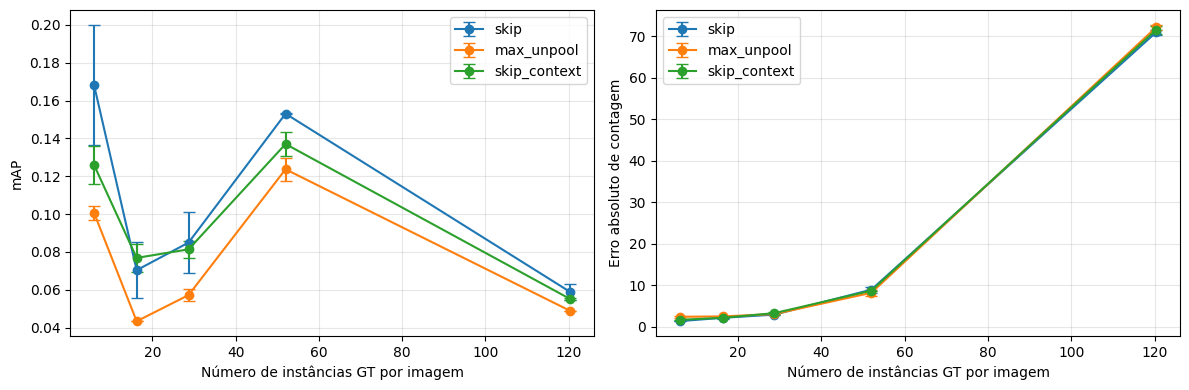

In [35]:
per_image_df['density_group'] = pd.cut(
    per_image_df['n_gt'],
    bins=[-0.5, 10, 20, 40, 60, np.inf],
    labels=['0–10', '11–20', '21–40', '41–60', '61+']
)

# Quantas imagens há em cada grupo (sem contar as corridas repetidas).
display(
    per_image_df.drop_duplicates('image_id')
    .groupby('density_group', observed=True).size().rename('n_images').to_frame()
)

density_per_seed = per_image_df.groupby(
    ['architecture', 'seed', 'density_group'], observed=True
)[['n_gt', 'mAP', 'count_absolute_error']].mean().reset_index()

density_summary = density_per_seed.groupby(
    ['architecture', 'density_group'], observed=True
).agg(
    n_gt=('n_gt', 'mean'),
    map_mean=('mAP', 'mean'),
    map_std=('mAP', 'std'),
    error_mean=('count_absolute_error', 'mean'),
    error_std=('count_absolute_error', 'std')
).reset_index()

density_summary.to_csv(output_dir / 'density_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name in names:
    data = density_summary[density_summary['architecture'] == name].sort_values('n_gt')

    axes[0].errorbar(
        data['n_gt'], data['map_mean'], yerr=data['map_std'],
        marker='o', capsize=4, label=name
    )
    axes[1].errorbar(
        data['n_gt'], data['error_mean'], yerr=data['error_std'],
        marker='o', capsize=4, label=name
    )

axes[0].set_ylabel('mAP')
axes[1].set_ylabel('Erro absoluto de contagem')
for ax in axes:
    ax.set_xlabel('Número de instâncias GT por imagem')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / 'density.png', dpi=180)
plt.show()


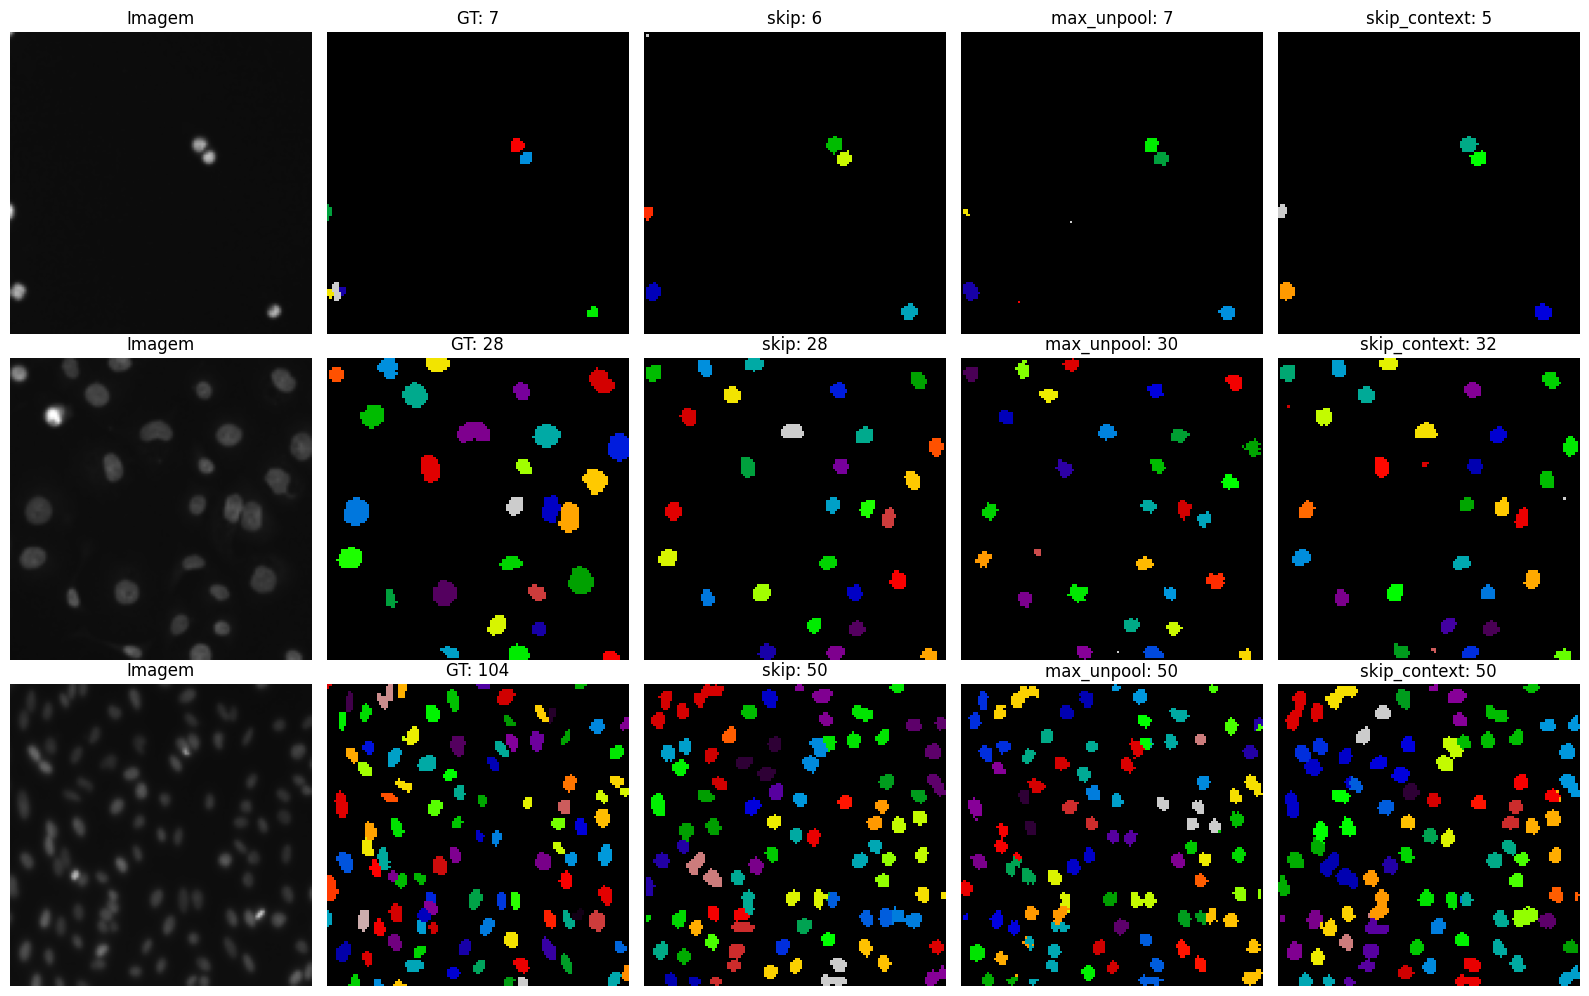

In [36]:
image_counts = per_image_df[['image_id', 'n_gt']].drop_duplicates('image_id')
image_counts = image_counts.sort_values(['n_gt', 'image_id']).reset_index(drop=True)
positions = [round(q * (len(image_counts) - 1)) for q in [0.1, 0.5, 0.9]]
selected_ids = image_counts.iloc[positions]['image_id'].tolist()

fig, axes = plt.subplots(3, 5, figsize=(16, 10))

for row, sample_id in enumerate(selected_ids):
    index = base_dataset.ids.index(sample_id)
    _, image, _, gt_map = base_dataset[index]

    axes[row, 0].imshow(image.permute(1, 2, 0).numpy())
    axes[row, 0].set_title('Imagem')
    axes[row, 1].imshow(gt_map.numpy(), cmap='nipy_spectral', interpolation='nearest')
    axes[row, 1].set_title(f'GT: {len(utils.get_instance_ids(gt_map.numpy()))}')

for col, name in enumerate(names, start=2):
    current_model = model_classes[name]().to(device)
    current_model.load_state_dict(torch.load(
        output_dir / f'{name}_seed42.pt', map_location=device, weights_only=True
    ))
    current_model.eval()

    for row, sample_id in enumerate(selected_ids):
        index = base_dataset.ids.index(sample_id)
        _, image, _, _ = base_dataset[index]

        with torch.no_grad():
            pred = current_model(image.unsqueeze(0).to(device))[0]
        pred_map = prediction_to_instances(pred)

        axes[row, col].imshow(pred_map, cmap='nipy_spectral', interpolation='nearest')
        axes[row, col].set_title(f'{name}: {len(utils.get_instance_ids(pred_map))}')

    current_model.cpu()
    del current_model

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig(output_dir / 'predictions.png', dpi=180)
plt.show()
